In [ ]:
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 11
Total threads: 11,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:57501,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:57527,Total threads: 1
Dashboard: http://127.0.0.1:57532/status,Memory: 1.64 GiB
Nanny: tcp://127.0.0.1:57504,


In [2]:
"""
This cell just opens a netcdf which is sitting in my users object storage on Pawsey.
Mostly intended as a demo that the dataset actually exists, and has the right settings
to be openeed by an anonymous user.
"""

import xarray as xr

url = "s3://zarr-data-stream-test/output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/tasmax/tasmax_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_201001-201012.nc"

ds = xr.open_dataset(
    url,
    engine="h5netcdf",
    backend_kwargs={
        "storage_options": {
            "anon": True,
            "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        }
    },
    chunks={},
    decode_times=False,
)

# This is just straight up opening the dataset on Pawsy
# ds['sst_m'].isel(time=0).plot()
ds

<xarray.Dataset> Size: 7MB
Dimensions:       (time: 12, rlat: 279, rlon: 364, rot_pole: 1, bnds: 2)
Coordinates:
  * time          (time) float64 96B 2.196e+04 2.199e+04 ... 2.226e+04 2.23e+04
  * rlat          (rlat) float64 2kB -11.34 -11.31 -11.27 ... -1.592 -1.557
  * rlon          (rlon) float64 3kB 147.7 147.7 147.7 ... 160.4 160.4 160.4
    lat           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    lon           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    rotated_pole  (rot_pole) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds     (time, bnds) float64 192B dask.array<chunksize=(12, 2), meta=np.ndarray>
    height        float64 8B ...
Dimensions without coordinates: rot_pole, bnds
Data variables:
    tasmax        (time, rlat, rlon) float32 5MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
Attributes: (12/28)
    institute_id:                   WA-DWER
    institution:                    Murdoch University and Department of Wate...
    contact:                        Jatin Kala (J.Kala@murdoch.edu.au), Sean ...
    references:                     https://www.wa.gov.au/organisation/depart...
    project_id:                     WA-CSI
    product:                        output
    ...                             ...
    wrf_shemes_ra_lw_physics:       Iacono, M. J., J. S. Delamere, E. J. Mlaw...
    wrf_shemes_sf_sfclay_physics:   Revised_MM5; Jimenez et al. (2012, MWR)
    wrf_shemes_sf_surface_physics:  Niu, Guo-Yue, Zong-Liang Yang, Kenneth E....
    wrf_shemes_mp_physics:          Thompson, Gregory, Paul R. Field, Roy M. ...
    wrf_shemes_bl_pbl_physics:      Nakanishi, M., and H. Niino, 2006: An imp...
    wrf_shemes_cu_physics:          Disabled

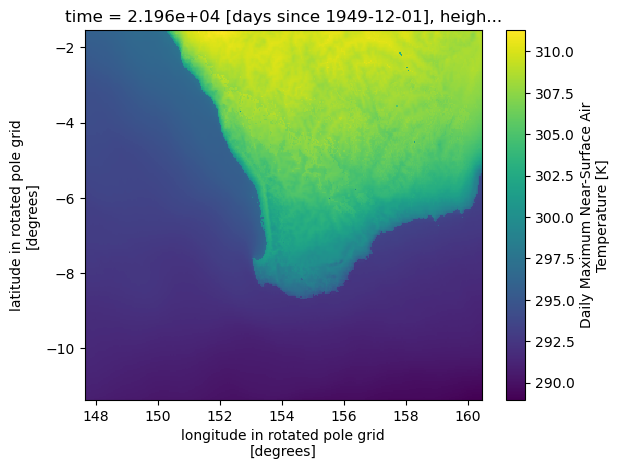

In [3]:
ds['tasmax'].isel(time=0).plot()

In [5]:
import warnings
import os
import xarray as xr
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from obstore.store import S3Store
from obspec_utils.registry import ObjectStoreRegistry

import numcodecs.zarr3  # Register the zarr3 codec

from dotenv import load_dotenv

load_dotenv()

access_key_id = os.environ.get("ATMOS_ACCESS_KEY_ID")
secret_access_key = os.environ.get("ATMOS_SECRET_ACCESS_KEY")
endpoint = "https://projects.pawsey.org.au"
bucket = "s3://zarr-data-stream-test"


# # create anon s3 store
# store = S3Store.from_url(f"{scheme}{path}", endpoint=endpoint, skip_signature=True)

# create s3 store with aws-style credentials
store = S3Store.from_url(
    f"{bucket}",
    endpoint=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
)

registry = ObjectStoreRegistry({f"{bucket}": store})

warnings.filterwarnings(
    "ignore",
    message="Numcodecs codecs are not in the Zarr version 3 specification*",
    category=UserWarning,
)
parser = HDFParser()

We now have proof that we can open that netcdf with virtualizarr. Let's now try opening the entire contents of that bucket as a single virtual dataset.

Following that, we'll try to save it via icechunk

In [6]:
import obstore

flist = []
for batch in obstore.list(store):
    for obj in batch:
        if obj.get("path","icechunk").startswith("icechunk"):
            pass

        if obj.get("path", "").startswith("output/SWWA"):
            flist.append(obj.get("path"))

print(flist[:10])

['output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198001-198012.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198101-198112.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198201-198212.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198301-198312.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198401-198412.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198501-198512.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198601-198612.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198701-198712.nc', 'output/SWWA/WA-DWER/ERA5/histo

In [7]:
urls = [f"{bucket}/{f}" for f in flist]

len(urls)

123

In [37]:
open_virtual_dataset(
    url = urls[1],
    parser=parser,
    registry=registry,
    decode_times=False,
)

ValueError: Shuffle buffer is not an integer multiple of elementsize

In [24]:
filepath = urls[0]
manifest_store = parser(
    url=filepath,
    registry=registry,
)


manifest_store._group.arrays['time_bnds'].manifest['0.0'].get('length')

np.uint64(59)

In [35]:
!cd ~ && curl -Os https://projects.pawsey.org.au/zarr-data-stream-test/output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/tasmax/tasmax_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_201001-201012.nc && h5dump -pH ~/tasmax_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_201001-201012.nc | tail -43

   DATASET "time_bnds" {
      DATATYPE  H5T_IEEE_F64LE
      DATASPACE  SIMPLE { ( 12, 2 ) / ( 12, 2 ) }
      STORAGE_LAYOUT {
         CHUNKED ( 12, 2 )
         SIZE 61 (3.148:1 COMPRESSION)
      }
      FILTERS {
         CHECKSUM FLETCHER32
         PREPROCESSING SHUFFLE
         COMPRESSION DEFLATE { LEVEL 5 }
      }
      FILLVALUE {
         FILL_TIME H5D_FILL_TIME_NEVER
         VALUE  H5D_FILL_VALUE_DEFAULT
      }
      ALLOCATION_TIME {
         H5D_ALLOC_TIME_INCR
      }
      ATTRIBUTE "DIMENSION_LIST" {
         DATATYPE  H5T_VLEN { H5T_REFERENCE { H5T_STD_REF_OBJECT } }
         DATASPACE  SIMPLE { ( 2 ) / ( 2 ) }
      }
      ATTRIBUTE "_Netcdf4Coordinates" {
         DATATYPE  H5T_STD_I32LE
         DATASPACE  SIMPLE { ( 2 ) / ( 2 ) }
      }
      ATTRIBUTE "_Netcdf4Dimid" {
         DATATYPE  H5T_STD_I32LE
         DATASPACE  SCALAR
      }
      ATTRIBUTE "long_name" {
         DATATYPE  H5T_STRING {
            STRSIZE 11;
            STRPAD H5T_STR_NULLTERM;

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config

s3 = boto3.client(
    "s3",
    endpoint_url="https://projects.pawsey.org.au",
    config=Config(signature_version=UNSIGNED),
)

resp = s3.get_object(
    Bucket="zarr-data-stream-test",
    Key="output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_201001-201012.nc",
    Range="bytes=4067642-4067702",
)
# open the bytes 
data = resp['Body'].read()
len(data)

import zlib
zlib.decompress(data)

error: Error -3 while decompressing data: incorrect header check

In [35]:
open_virtual_mfdataset(
    urls=urls,
    parser=parser,
    registry=registry,
    combine="nested",
    concat_dim="time",
    parallel="dask",
    compat="override",
    coords="minimal",
    drop_variables=['time_bnds'],  
    decode_times=False,
)

ValueError: Shuffle buffer is not an integer multiple of elementsize

In [14]:
# Copied from `~/scratch/virtualizarr/test_nb.ipynb`
# Just using to save the combined virtual dataset as a zarr via icechunk, so we
# don't have to fetch it from pawsey to rebuild it there if something crashes
import xarray as xr
import icechunk
from pathlib import Path

if Path("/Users/u1166368/PawseyVirtualisationTests/pawsey/atmos-daily").exists():
    import shutil
    shutil.rmtree("/Users/u1166368/PawseyVirtualisationTests/pawsey/atmos-daily")

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

# credentials = icechunk.containers_credentials(
#     { "s3://my_s3_bucket": icechunk.s3_credentials(bucket="my-s3-bucket", region="us-east-1"),
#       "s3://my_other_s3_bucket": icechunk.s3_credentials(bucket="my-other-s3-bucket", region="us-west-2"),
#     }
# )

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.local_filesystem_storage("/Users/u1166368/PawseyVirtualisationTests/pawsey/atmos-daily")
repo = icechunk.Repository.create(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
combined_vds.vz.to_icechunk(write_session.store)
write_session.commit("Write Pawsey atmos virtual dataset to local zarr store for testing")

  2026-03-13T12:22:53.940678Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:81



'Z09XPS5KA6Q6GNMS43RG'

In [ ]:
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.local_filesystem_storage("/Users/u1166368/scratch/virtualizarr/pawsey/01deg")
repo = icechunk.Repository.open(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
session = repo.readonly_session("main")
xr.open_zarr(session.store, consolidated=False)['sst_m'].isel(time=0).plot()

In [ ]:
import matplotlib.pyplot as plt
_arr = xr.open_zarr(session.store, consolidated=False)['sst_m'].data.blocks[0,0,0].compute().squeeze()
plt.pcolor(_arr)

### Works locally - so write to pawsey

In [17]:
# Now put the virtual dataset in the bucket alongside the netcdf files
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.s3_storage(
    bucket='ct-zarr-test',
    prefix='icechunk',
    endpoint_url=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    force_path_style=True,
)
repo = icechunk.Repository.create(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
combined_vds.vz.to_icechunk(write_session.store)
write_session.commit("Write Pawsey 01deg virtual dataset to acacia zarr store for testing")

  2026-03-13T13:05:39.586457Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: io error: client error (Connect): tcp connect error: Host is down (os error 64) (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Io, source: hyper_util::client::legacy::Error(Connect, ConnectError("tcp connect error", 169.254.169.254:80, Os { code: 64, kind: Uncategorized, message: "Host is down" })), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



'P4R2PHB0ZG1HW7BX1NJ0'

In [ ]:
combined_vds

In [18]:
# And write to a local kerchunk container using json
combined_vds.vz.to_kerchunk(
    filepath="/Users/u1166368/PawseyVirtualisationTests/pawsey/ref-atmos-daily.pq",
    format='parquet',
)

KeyError: 'height/.zarray'

In [ ]:
import fsspec

refs = combined_vds.vz.to_kerchunk(format='dict')

with fsspec.open(
    "s3://01deg/reference.json",
    "wb",
    client_kwargs={"endpoint_url": endpoint},
    key=access_key_id,
    secret=secret_access_key,
) as f:
    import json
    f.write(json.dumps(refs).encode("utf-8"))

In [ ]:
# And try as parquet too
combined_vds.vz.to_kerchunk(
    filepath="file:///Users/u1166368/scratch/virtualizarr/pawsey/ref-01deg.pq",
    format='parquet',
    record_size=50_000
)

In [ ]:
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

In [19]:
import icechunk
from dotenv import load_dotenv
load_dotenv()

access_key_id = os.environ.get("ATMOS_ACCESS_KEY_ID")
secret_access_key = os.environ.get("ATMOS_SECRET_ACCESS_KEY")

endpoint = "https://projects.pawsey.org.au"
bucket = "s3://ct-zarr-test"

storage = icechunk.s3_storage(
    bucket='ct-zarr-test',
    prefix='icechunk',
    endpoint_url=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    force_path_style=True,
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

repo = icechunk.Repository.open(storage=storage, config=None, authorize_virtual_chunk_access=credentials)

session = repo.readonly_session("main")

  2026-03-13T13:10:21.583318Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



In [20]:
xr.open_zarr(session.store, consolidated=False)

  2026-03-13T13:10:28.435146Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



<xarray.Dataset> Size: 71GB
Dimensions:             (time: 15218, lat: 144, lon: 192, depth: 6, bnds: 2)
Coordinates:
  * depth               (depth) float64 48B 0.011 0.051 0.157 0.4385 1.185 3.164
    height              float64 8B ...
  * lat                 (lat) float64 1kB -89.38 -88.12 -86.88 ... 88.12 89.38
  * lon                 (lon) float64 2kB 0.9375 2.812 4.688 ... 357.2 359.1
    height_0            float64 8B ...
  * time                (time) datetime64[ns] 122kB 1970-01-01T12:00:00 ... 2...
Dimensions without coordinates: bnds
Data variables: (12/32)
    fld_s00i049         (time, lat, lon) float32 2GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    depth_bnds          (time, depth, bnds) float64 1MB dask.array<chunksize=(1, 6, 2), meta=np.ndarray>
    fld_s00i031         (time, lat, lon) float32 2GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    fld_s02i201         (time, lat, lon) float32 2GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    fld_s02i206         (time, lat, lon) float32 2GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    fld_s00i507         (time, lat, lon) float32 2GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    ...                  ...
    fld_s38i520         (time, lat, lon) float32 2GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    fld_s05i216         (time, lat, lon) float32 2GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    lat_bnds            (time, lat, bnds) float64 35MB dask.array<chunksize=(1, 144, 2), meta=np.ndarray>
    lon_bnds            (time, lon, bnds) float64 47MB dask.array<chunksize=(1, 192, 2), meta=np.ndarray>
    time_bnds           (time, bnds) datetime64[ns] 243kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_longitude  (time) int32 61kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    history:      File /scratch/p66/dhb599/archive//bx944/history/atm/bx944a....
    Conventions:  CF-1.6
    source:       Data from Met Office Unified Model
    um_version:   10.6

In [ ]:
xr.open_zarr(session.store, consolidated=False)['sst_m'].isel(time=0).sel(ni=slice(0,1000), nj=slice(500,1250)).plot()

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr

xr.open_zarr(session.store, consolidated=False)['sst_m'].isel(time=0).sel(ni=slice(2600,3000), nj=slice(1600,2000)).plot()

In [ ]:
import xarray as xr

url = "s3://01deg/reference.json"

ds = xr.open_dataset(
    url,
    backend_kwargs={
        "storage_options": {
            "anon": True,
            "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        }
    },
)
ds['sst_m'].isel(time=0, ni=slice(400,1350), nj=slice(0,1200)).plot()

In [ ]:
import xarray as xr
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

url = "/Users/u1166368/scratch/virtualizarr/pawsey/ref-01deg.json"

# This is a bit of a mouthful...
ds = xr.open_dataset(
    "reference://", engine="zarr",
    backend_kwargs={
        "storage_options": {
            "fo": url,
            "remote_protocol": "s3",
            "remote_options": {
                "asynchronous": True, 
                "anon": True,
                "endpoint_url": "https://projects.pawsey.org.au",
                }
        },
        "consolidated": False
    }, 
)
ds

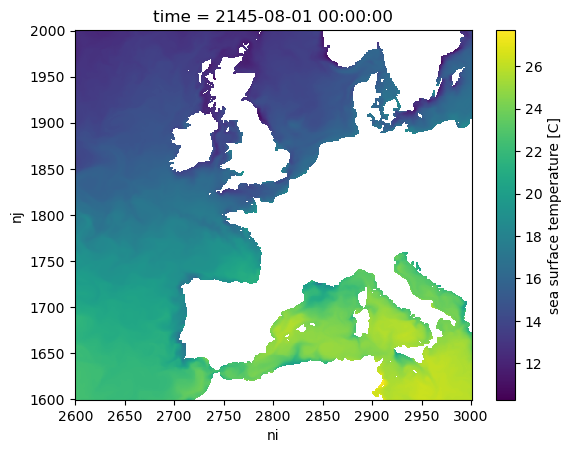

In [3]:
ds['sst_m'].isel(time=0).sel(ni=slice(2600,3000), nj=slice(1600,2000)).plot()

In [ ]:
# Takes about 0.5-1S to stream and plot this lovely map of THE WORLD ACCORDING TO 
# THE ENGLISH (I chose this because of it's relatively small area)

In [ ]:
client.close()